# Tarea 2

#### Instrucciones:
- La tarea consta de una parte de preguntas y otra de desarrollo de código. Debe entregar todas las respuestas en formato notebook, y cuando la respuesta sea texto, debe hacer en celdas markdown con formato. 
- La entrega de la Tarea es el día **18 de Octubre, 23:59 hrs.**

## Parte 1: Árboles de decisión y kNN

Las preguntas a continuación se refieren a el set de "juguete" de Habitabilidad de Planetas visto en clases. Responda con texto (en celda markdown con formato) y/o con código, según corresponda. 

**1. Si tuviera que eliminar un feature que no cambie la performance demasiado, cuál sería y por qué?**

In [1]:
import pandas as pd
LearningSet = pd.read_csv('HPLearningSet.csv')

In [2]:
LearningSet = LearningSet.drop(LearningSet.columns[0], axis=1) 
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [3]:
LearningSet = LearningSet.drop(LearningSet.columns[0], axis=1) 
LearningSet

,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,0.86,3.601472,0.043718,0
1,0.85,16.080661,0.118082,0
2,1.19,7.638460,0.080420,0
3,0.61,112.305300,0.409327,1
4,0.98,12.992073,0.107408,0
5,0.09,4.910000,0.025200,1
6,0.69,4.655411,0.048086,0
7,0.12,6.689000,0.035000,1
8,1.12,1103.000000,2.180981,0
9,0.81,168.811170,0.557107,1


<Axes: >

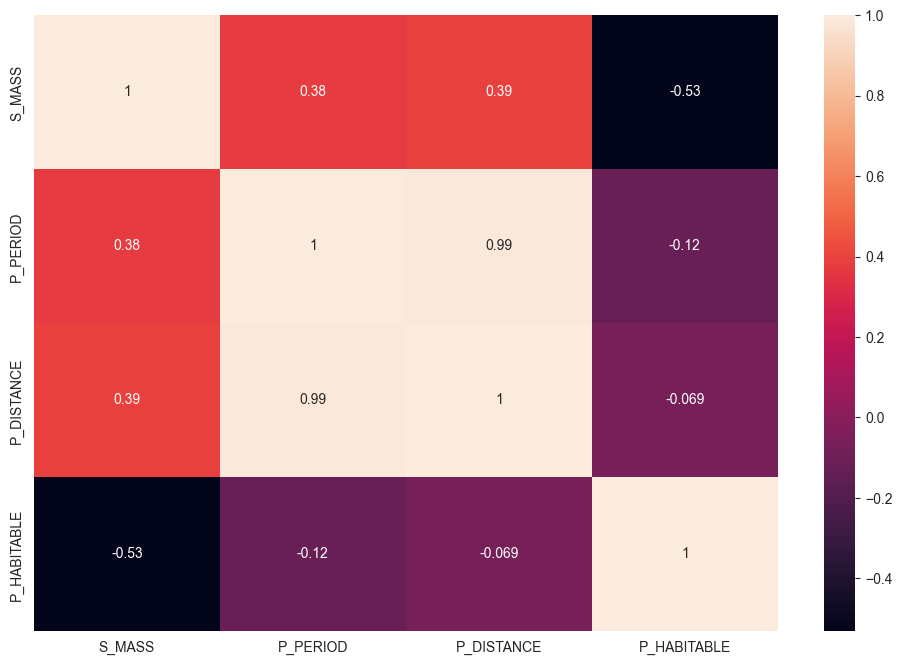

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid') 

plt.figure(figsize = (12, 8))
sns.heatmap(LearningSet.corr(),annot = True)

La masa es la feature que al eliminarla, no cambiaría mucho el resultado, debido a que es la variable que menos se correlaciona con la target P_HABITABLE.

**2. En clases, usamos k=3 vecinos para el algoritmo kNN. Usted recomendaría aumentar el número de vecinos usados para clasificación en este set de datos?  Por qué? (Puede dar una justificación con una explicación o a través de código, no hay puntos sin justificación)**

No recomendamos aumentar el número de vecinos, ya que el set de datos es pequeño, por lo tanto al aumentar la cantidad, kNN consideraría un porcentaje significativo del total de los datos, lo cual podría introducir un bias a nuestro algoritmo. Además, vemos que al aumentar el valor de k, disminuye el número de predicciones correctas.

In [5]:
from sklearn import neighbors 
import sklearn

LearningSet = pd.read_csv('HPLearningSet.csv')

In [6]:
TrainSet =  LearningSet.iloc[:13,:] 

TestSet = LearningSet.iloc[13:,:]

In [7]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) 

Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1)  

In [8]:
ytrain = TrainSet.P_HABITABLE 

ytest = TestSet.P_HABITABLE 

In [9]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3)

In [10]:
from sklearn import metrics
model.fit(Xtrain.iloc[:,1:],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,1:]) #esto ajsta el modelo en los datos de prueba
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,1:]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento

print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,1:]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


In [11]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

In [12]:
model2 = neighbors.KNeighborsClassifier(n_neighbors = 5)
model2.fit(Xtrain.iloc[:,1:],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model2.predict(Xtest.iloc[:,1:]) #esto ajsta el modelo en los datos de prueba
print(ytestpred, ytest.values)
print(metrics.accuracy_score(ytrain, model2.predict(Xtrain.iloc[:,1:]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento
print(metrics.accuracy_score(ytest, model2.predict(Xtest.iloc[:,1:]))) #mismo que anterior, pero para set de prueba

[0 0 1 0 0] [0 0 1 0 1]
0.6153846153846154
0.8


Observando estos valores, el modelo no tiene suficiente complejidad, y por lo tanto, realiza un subajuste. Esto se podría solucionar agregando más features, o probando con un algoritmo más complejo.

**3. Si usted usara los dos árboles de decisión que vimos en el notebook de ejemplo en clases (usando los 13 primeros datos como set de entrenamiento, y luego, los 13 últimos), para clasificar a la Tierra como habitable, cuál sería su veredicto? (Muestre su línea de pensamiento o código, no hay puntos sin justificación). Qué conclusión puede sacar de este resultado?** 


Utilizando los primeros o últimos 13 datos como set de entramiento, se obtiene que la Tierra no sería un planeta Habitable. 

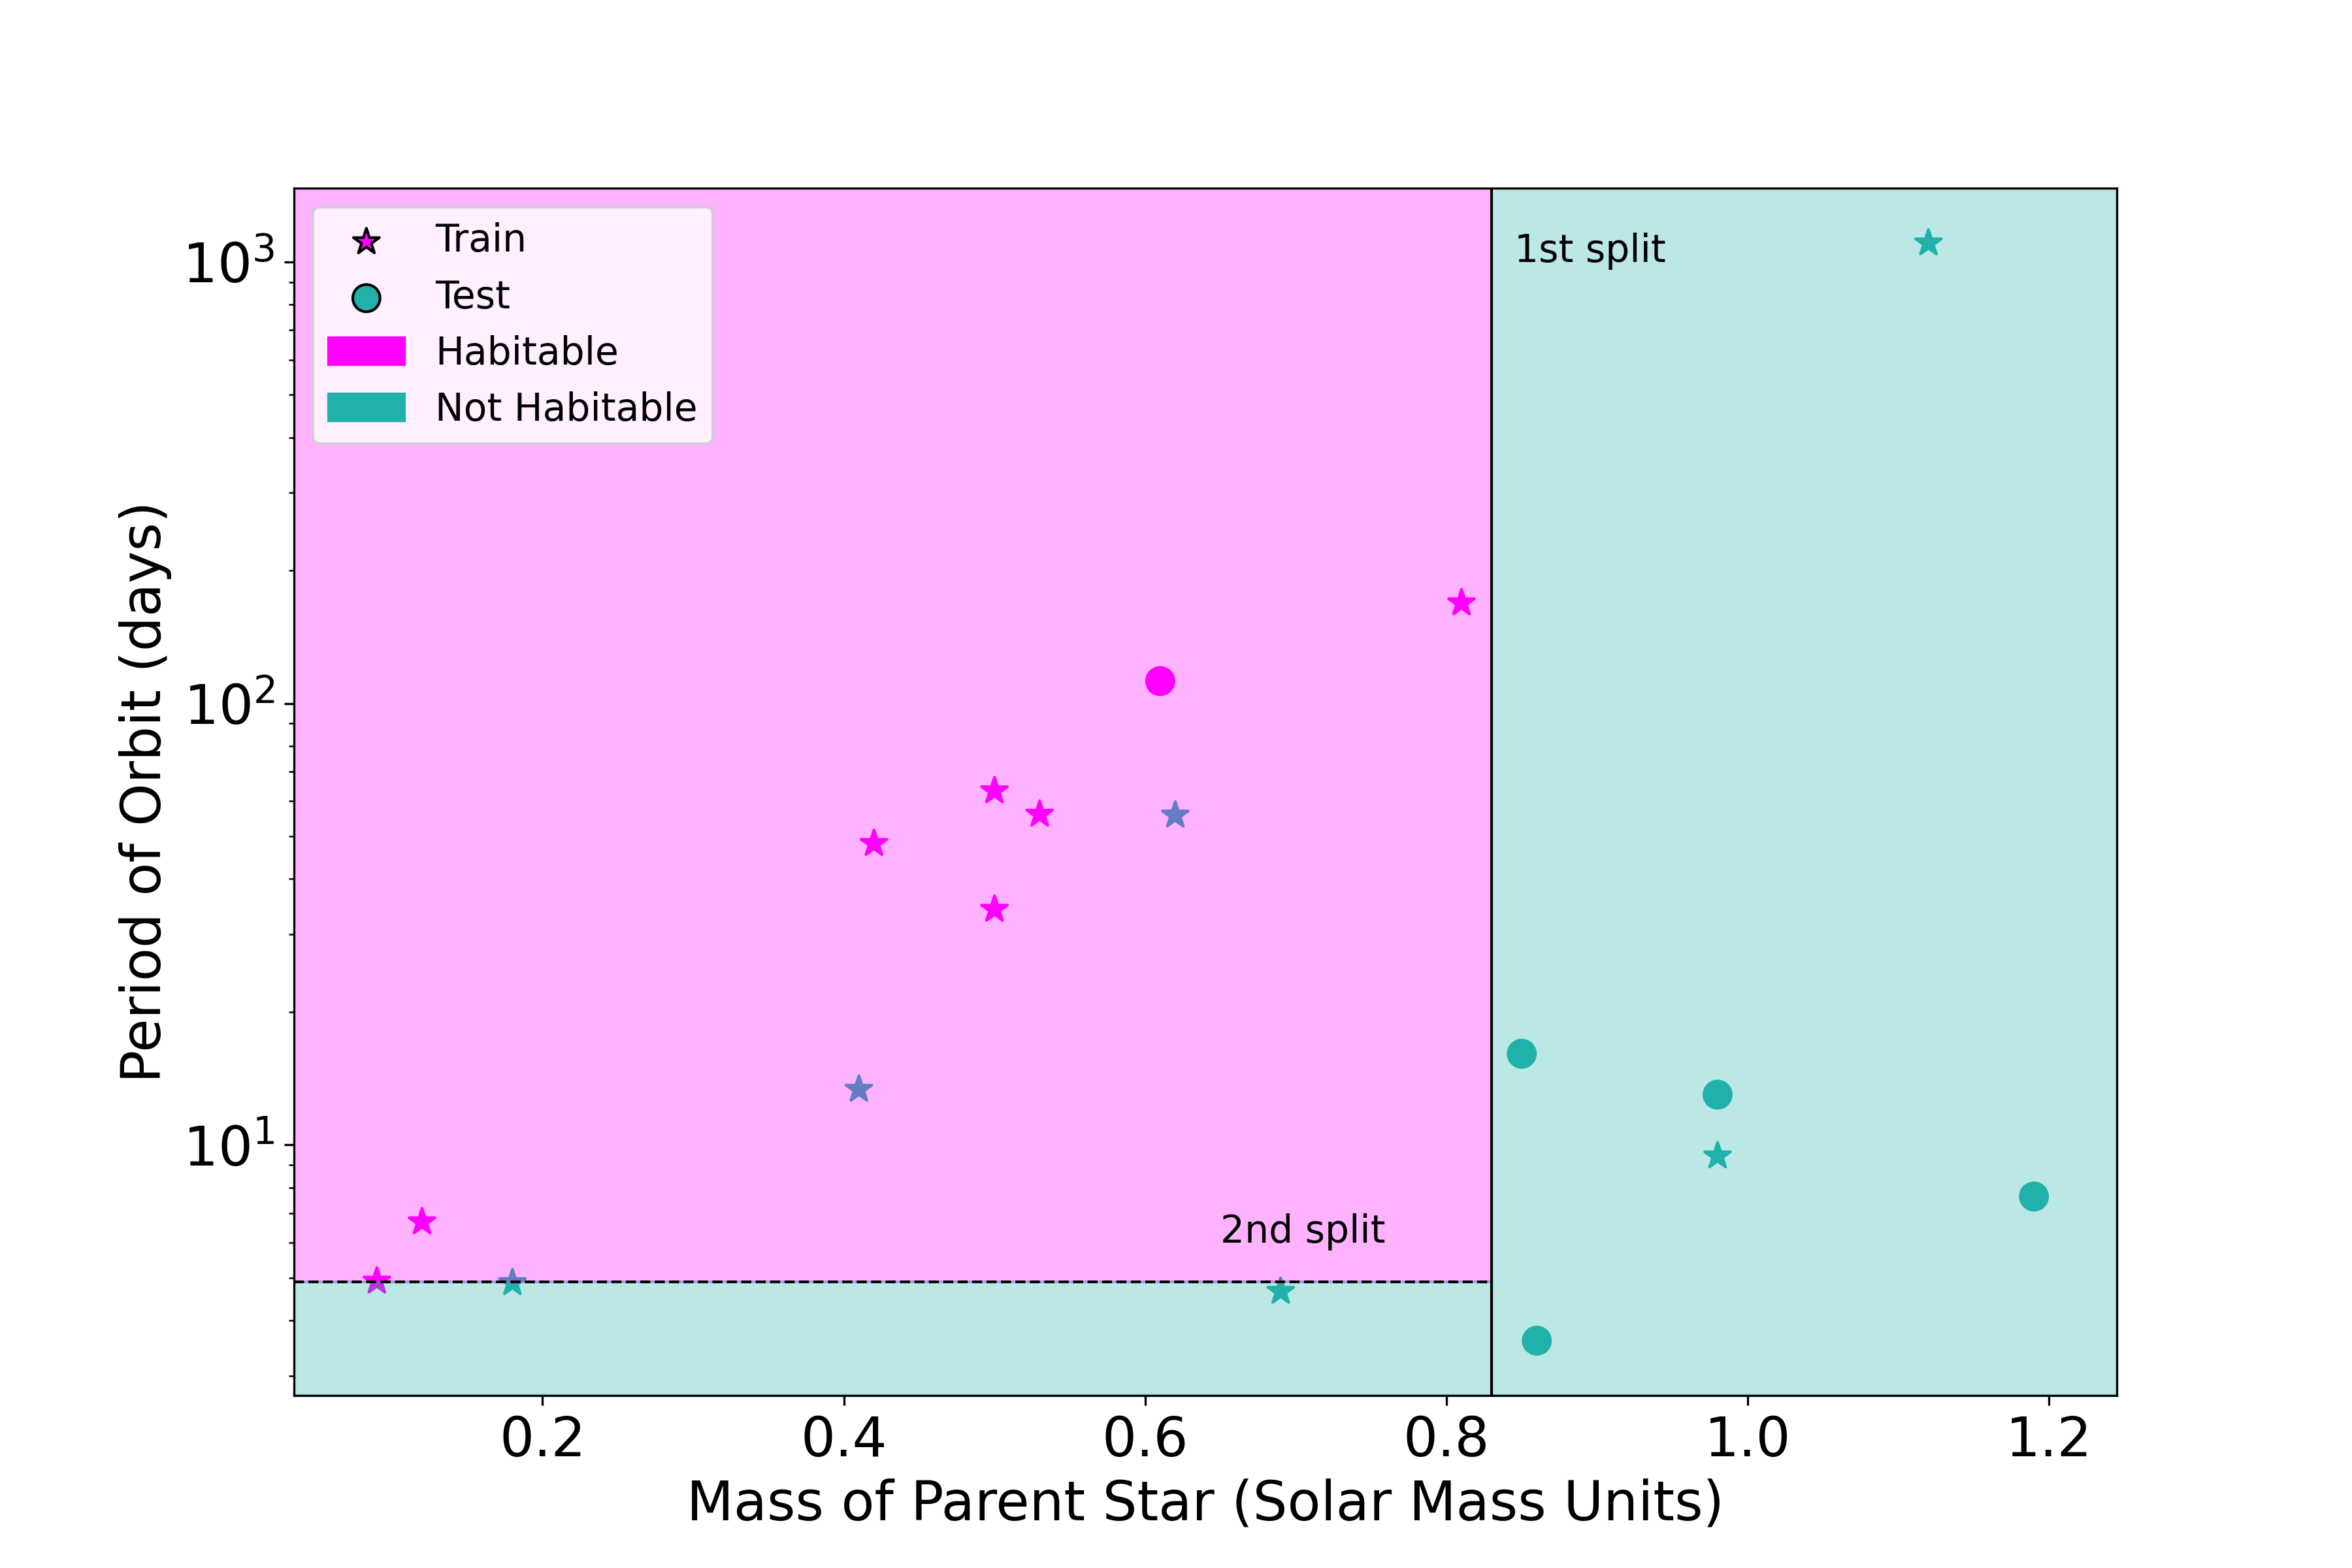
(Primeros 13 como entrenamiento)

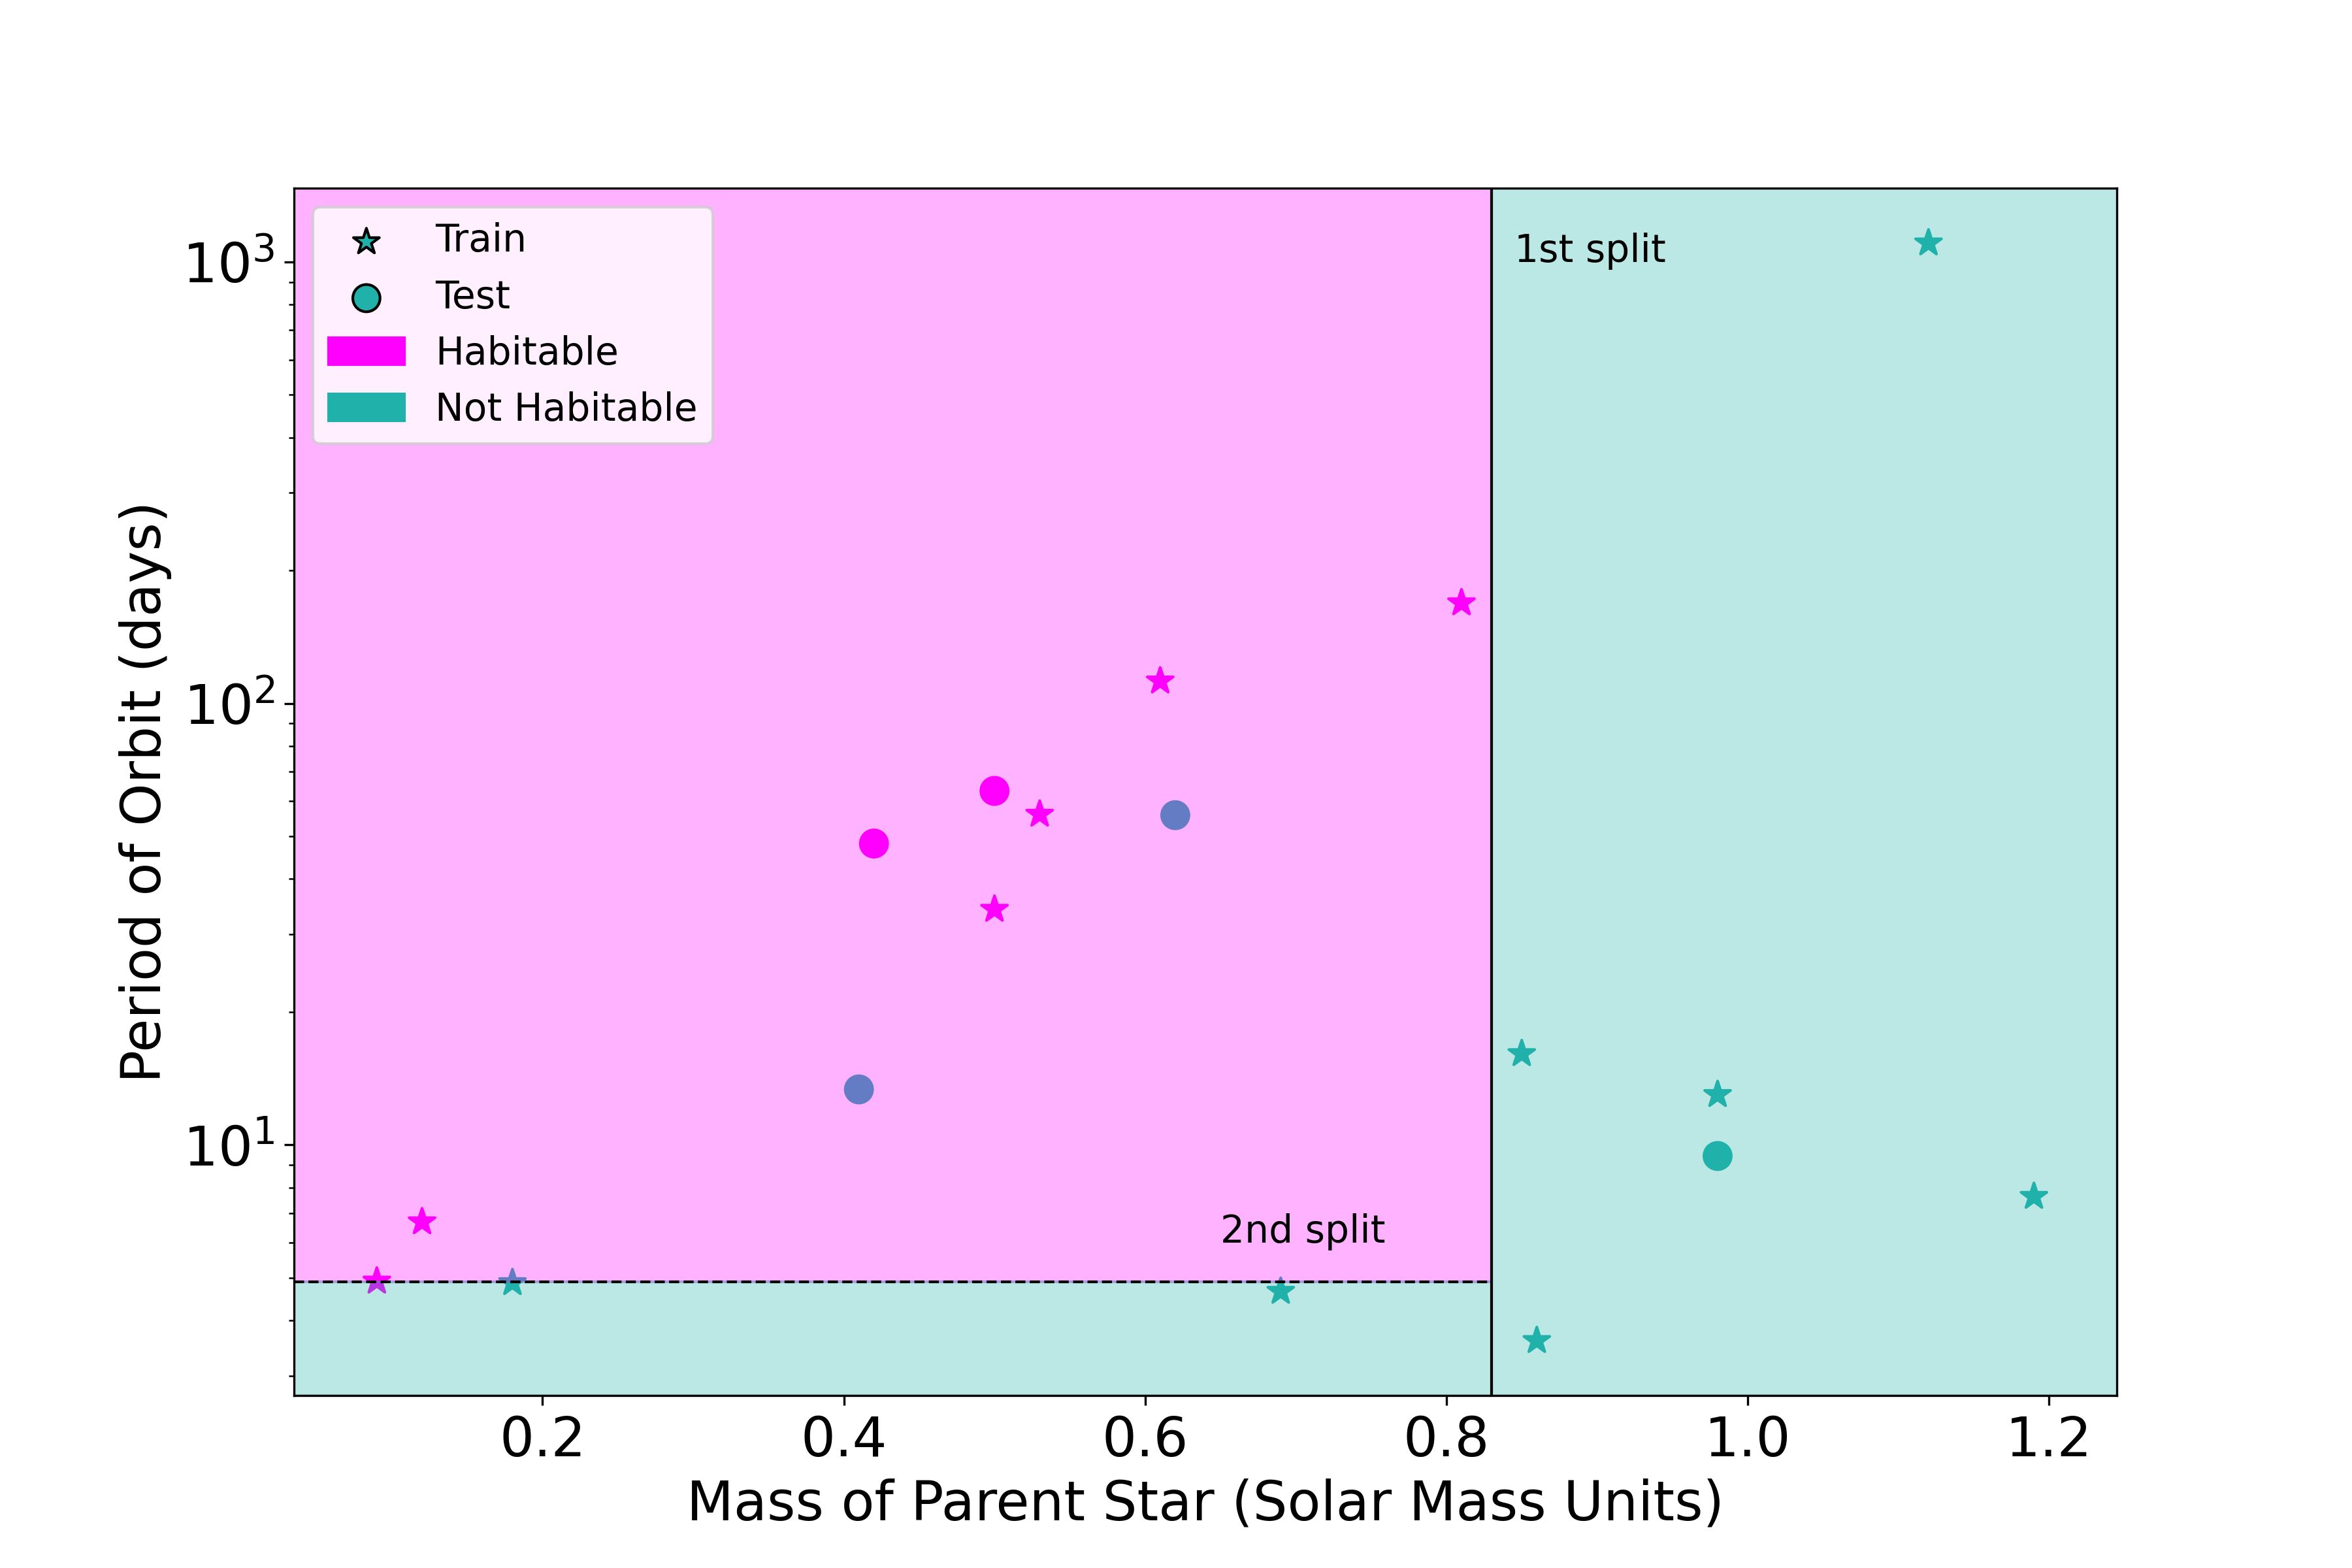
(Últimos 13 como entrenamiento)

Esto claramente es incorrecto, lo que quiere decir que este modelo de predicción no es confiable. Como mencionamos anteriormente, esto podría deberse a una falta de features. Además, sería conveniente agregar más datos, para que el modelo se entrene de mejor manera.

## Parte 2: Métricas y diagnóstico de algoritmos de clasificación usando datos de Variables RR Lyrae 

A continuación, usted deberá desarrollar el código necesario para implementar un algoritmo de árbol de decisión sobre un set de datos de RR Lyrae. Los archivos necesarios son 'RRLyrae_features_small.txt' y 'RRLyrae_labels_small.txt'. Las preguntas son una guía para todo el proceso. Recuerde hacer comentarios sobre su código para mejor comprensión.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.model_selection import cross_validate, cross_val_predict
#puede agregar cualquier otra librería que necesite

#### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros, que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae. Los valores target serán entonces sí/no (0/1)



**1\. Cargue los datos de features y targets de los archivos entregados y guardelos en arreglos en numpy o dataframes, listos para ser usados por sklearn**

In [14]:
RRLyrae_features = pd.read_csv('RRLyrae_features_small.txt', header=None)
RRLyrae_labels = pd.read_csv('RRLyrae_labels_small.txt', header=None)

In [15]:
RRLyrae_features

,0,1,2,3
0,0.311,0.714,0.093,0.204
1,0.332,0.965,0.122,0.032
2,0.394,1.019,0.147,0.096
3,0.285,0.865,0.120,0.039
4,0.386,0.977,0.181,0.080
...,...,...,...,...
2478,0.059,0.963,-0.026,-0.025
2479,0.185,1.060,0.051,-0.024
2480,0.212,1.044,0.035,0.002
2481,0.172,1.065,0.042,0.003


**2\. Responda las siguientes preguntas y justifique su respuesta:**

**a) ¿esto es un problema de clasificación o regresión?**

Es un problema de clasificación, ya que se busca predecir si la estrella es RR Lyrae o no. Las opciones son discretas.

**b) ¿es esto aprendizaje supervisado o no supervisado?**

Es aprendizaje supervisado, debido a que el modelo para predecir la clasificación, será entrenado con estrellas que ya se conoce previamente si es RR Lyrae o no. En cambio un modelo de aprendizaje no supervisado, no se tienen las etiquetas, ni se espera predecir algo especificamente, sino buscar patrones presentes en el set de datos.

**c) ¿Cuántas instancias hay en el set de datos?**

El set de datos posee 2483 instancias.

**d) ¿Cuántas características hay?**

Hay 4 características, estas son los colores en distintos filtros

**e) ¿Cuántos ejemplos de la clase positiva hay?**

In [16]:
RRLyrae_labels.sum()

0    483
dtype: int64

Existen 483 estrellas de la clase negativa (1), por lo tanto, son 2000 de la clase positiva (0). 2000 son RR Lyrae.

**3\. Use un árbol de decisión e implemente validación cruzada con k-fold (use la sintáxis de la segunda celda más abajo)**

In [17]:
model = DecisionTreeClassifier(random_state=10)

In [18]:
# cambie X e y apropiadamente, según usted nombró a sus arrays
scores = cross_validate(model, RRLyrae_features, RRLyrae_labels, cv=10,return_train_score=True) 

In [19]:
scores

{'fit_time': array([0.02209187, 0.0100832 , 0.01506734, 0.00857162, 0.0095408 ,
        0.01052999, 0.00952911, 0.00853252, 0.00960064, 0.01157212]),
 'score_time': array([0.00554609, 0.0060339 , 0.00959659, 0.00957918, 0.00455093,
        0.00353408, 0.00357485, 0.00401235, 0.00752425, 0.00352764]),
 'test_score': array([0.95180723, 0.95582329, 0.95983936, 0.97580645, 0.97580645,
        0.93548387, 0.97983871, 0.97580645, 0.94758065, 0.95967742]),
 'train_score': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])}

**4\. Reporte los scores de entrenamiento y prueba  y calcule el promedio y la desviación estándar del vector de scores**

In [20]:
train_scores = scores['train_score']
test_scores = scores['test_score']

print("Scores de entrenamiento:", train_scores)
print("Scores de prueba:", test_scores)

Scores de entrenamiento: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Scores de prueba: [0.95180723 0.95582329 0.95983936 0.97580645 0.97580645 0.93548387
 0.97983871 0.97580645 0.94758065 0.95967742]


In [21]:
test_mean = np.mean(test_scores)
test_std = np.std(test_scores)

print(f"\nPromedio del score de prueba: {test_mean:.4f}")
print(f"Desviación estándar del score de prueba: {test_std:.4f}")


Promedio del score de prueba: 0.9617
Desviación estándar del score de prueba: 0.0140


In [22]:
train_mean = np.mean(train_scores)
train_std = np.std(train_scores)

print(f"\nPromedio del score de entrenamiento: {train_mean:.4f}")
print(f"Desviación estándar del score de entrenamiento: {train_std:.4f}")


Promedio del score de entrenamiento: 1.0000
Desviación estándar del score de entrenamiento: 0.0000


**5\. Imprima la matriz de confusión para su modelo (solo muestre los valores, no tienen que hacer una figura bonita, pero si quiere, puede hacerlo). Para generar las predicciones, puede usar la función "cross_val_predict"**

In [23]:
ypred = cross_val_predict(model,RRLyrae_features,RRLyrae_labels,cv=5)

In [40]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(RRLyrae_labels, ypred)

In [41]:
cm

array([[1958,   42],
       [  43,  440]])

**6\. En base a la matriz de confusión, cuántos verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos tiene?**

Existen 1958 verdaderos positivos, 440 verdaderos negativos, 42 falsos positivos, y 43 falsos negativos.

**7\. Usando sólo las definiciones (no funciones implementadas en python), calcule accuracy, precision y recall. Escriba todos los pasos**

Las métricas de evaluación están descritas por las siguientes expresiones:

$$ \text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}$$
$$ \text{Precision} = \frac{TP}{TP+TF}$$
$$ \text{Recall} = \frac{TP}{TP+FN}$$

Por lo tanto, tenemos que:

In [44]:
accuracy_RR = (1958+440)/(1958+440+42+43)
accuracy_RR 

0.9657672170761176

In [45]:
precision_RR = 1958/(1958+42)
precision_RR

0.979

In [46]:
recall_RR = 1958/(1958+43)
recall_RR

0.9785107446276862

**8\. ¿Qué metrica de evaluación usa CV en la pregunta 4? (Ayuda: Revise la descripción de la función). De acuerdo a la distribución de las clases en su dataset, existe algún problema con las métricas que use?**

En la página de la documentación de [cross_validation](https://scikit-learn.org/stable/modules/cross_validation.html#multimetric-cross-validation) de scikit-learn, se detalla que por defecto, el score se calcula utilizando la métrica que utiliza el *estimator*, en este caso, el arbol de decisión. Respecto a este estimator, en su [documentacion](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.score) se tiene que el score el **mean accuracy**.

Esta métrica no es muy conveniente o recomendable según la distribución de nuestro dataset, ya que este es desbalanceado, es decir, tiene muchas más clases positivas que clases negativas. Esto significa que el valor de accuracy puede ser alto incluso si el modelo no haace buenas predicciones para la clase con menos instancias (clase negativa).

**9\. Otras métricas puede verlas en la celda abajo**

In [53]:
print(metrics.accuracy_score(RRLyrae_labels, ypred))    
print(metrics.recall_score(RRLyrae_labels, ypred))     
print(metrics.precision_score(RRLyrae_labels, ypred))   
print(metrics.f1_score(RRLyrae_labels, ypred))

0.9657672170761176
0.9109730848861284
0.9128630705394191
0.9119170984455959


Notamos que los valores de las métricas Precision y Recall son diferentes a los que obtuvimos en la pregunta **7**. Leyenda la documentación de estas métricas, vimos que existe un parámetro llamado *average*, este por defecto es *'binary'*, lo que significa que calcula el score para la label 1, es decir, para las estrellas que no son RR Lyrae, o bien, la clase negativa. Al fijar este parámetro como *average = None*, la función retorna el score de ambas etiquetas:

In [55]:
print(metrics.recall_score(RRLyrae_labels, ypred, average=None))     
print(metrics.precision_score(RRLyrae_labels, ypred, average=None))   


[0.979      0.91097308]
[0.97851074 0.91286307]


Vemos que el primer score de ambos resultados, es consistente con el que calculamos anteriormente. Este es el score para la etiqueta 0, es decir, la clase positiva. Debido a que F1 es dependiente de precision y recall, también cambiaremos el parámetro mencionado para esta métrica.

In [59]:
print(metrics.f1_score(RRLyrae_labels, ypred, average=None))

[0.97875531 0.9119171 ]


**¿Qué pasa con cada métrica de arriba si cambia de posición *y* y *ypred*?**


In [57]:
print(metrics.accuracy_score(ypred, RRLyrae_labels))
print(metrics.recall_score(ypred, RRLyrae_labels, average=None))
print(metrics.precision_score(ypred, RRLyrae_labels, average=None))
print(metrics.f1_score(ypred, RRLyrae_labels))

0.9657672170761176
[0.97851074 0.91286307]
[0.979      0.91097308]
0.9119170984455959


Podemos ver que que el **Accuracy** no cambió, al igual que **F1_score**, a diferencia de **Recall** y **precision** que si tuvieron una leve variación. Esto podría deberse a que la métrica accuracy se enfoca en las predicciones correctas, independientemente de su etiqueta. En el caso de las métricas que presentan un cambio, notamos que el resultado de precision es el mismo que el resultado de Recall antes de invertir las posiciones, y viceversa. Esto ocurre ya que estas métricas son dependientes de la clase, por lo tanto, al invertir el orden de las variables en la función, también se invierten las clases, por lo tanto, se altera la métrica.

**Para comparar la performance, usaremos el F1 score**

**F1 = 2 * (precision * recall) / (precision + recall)**

**10\. incluya el cálculo de F1_score como argumento opcional de cross_validate y reporte el promedio y desviación estándar de los puntajes obtenidos**

In [58]:
precision = 0.97851074 
recall = 0.979

F1_score = 2 * (precision * recall) / (precision + recall)
F1_score

0.9787553088572072

In [71]:
from sklearn.metrics import make_scorer, f1_score


scoring = make_scorer(f1_score)

results = cross_validate(model, RRLyrae_features, RRLyrae_labels, cv=5, scoring=scoring)

f1_scores = results['test_score']
print("F1 scores por fold:", f1_scores)

print("{:.3f}".format(results['test_score'].mean()), "{:.3f}".format(results['test_score'].std()))

F1 scores por fold: [0.89361702 0.94472362 0.8989899  0.95384615 0.88043478]
0.914 0.029


**11\. Para hacer diagnóstico, use cross_validate con 'return_train_score = True'. Compare el f1 score para entrenamiento y prueba obtenido por su modelo. Basado en este resultado, el algoritmo sufre de varianza alta o sesgo alto? por qué?**

In [33]:
results = cross_validate(model, RRLyrae_features, RRLyrae_labels, cv=5, scoring=scoring, return_train_score=True)
train_f1_scores = results['train_score']
test_f1_scores = results['test_score']


print("Train_f1_score:", train_f1_scores)
print("Train_promedio:", train_f1_scores.mean())
print("Train_desviación:", train_f1_scores.std())

# Imprimir los valores de F1 scores para prueba
print("Test_f1_score:", test_f1_scores)
print("Test_promedio:", test_f1_scores.mean())
print("Test_desviación:", test_f1_scores.std())

Train_f1_score: [1. 1. 1. 1. 1.]
Train_promedio: 1.0
Train_desviación: 0.0
Test_f1_score: [0.88421053 0.93467337 0.9035533  0.95384615 0.88043478]
Test_promedio: 0.9113436258194391
Test_desviación: 0.02864609071429953


Si nos fijamos en los valores de Train_f1_score, podemos observar que tenemos un f1_score de 1 en todos los set de entrenamiento (osea que hay alta precisión), por lo tanto el promedio es de 1, y logicamente no tiene desviación estandar, pues todos los valores son iguales.

En el conjunto de prueba el f1_score tiene valores levemente más bajos en comparación con el conjunto de entrenamiento, podemos observar que en todos los set los valores son muy cercanos a 1, siendo el promedio de 0.9113 (muy cercano a 1, osea, casi perfecto) y la desviación, como era de esperar tiene un valor bajo, de 0.0286.

**12\. Usando el código del ejemplo en el notebook de métricas, grafique las curvas de aprendizaje. Necesitamos más datos de entrenamiento? Justifique su respuesta**


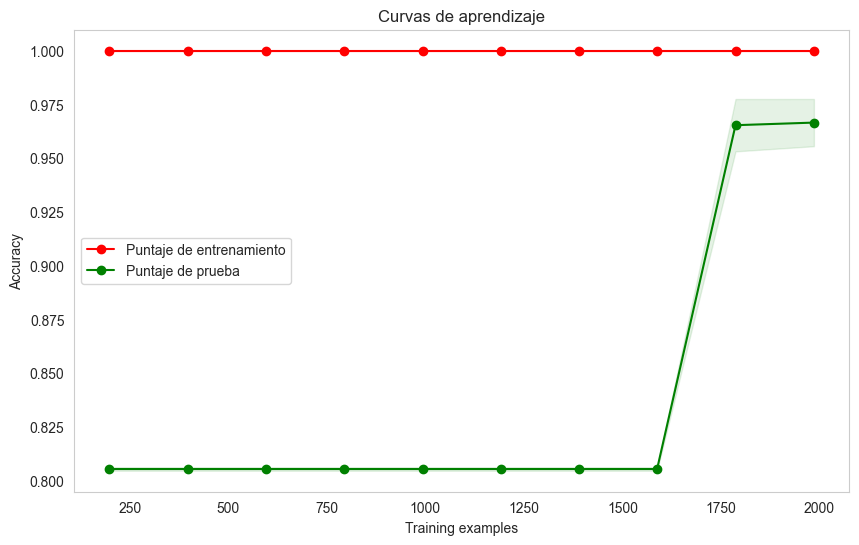

In [72]:
from sklearn.model_selection import learning_curve
def plot_learning_curve(estimator, X, y, cv=5, scoring='accuracy', n_jobs=None):
    """Grafica las curvas de aprendizaje para el modelo."""
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)
    
    # Calcular los promedios y desviaciones estándar para los puntajes de entrenamiento y prueba
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Graficar las curvas de aprendizaje
    plt.figure(figsize=(10, 6))
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Puntaje de entrenamiento")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Puntaje de prueba")

    plt.title("Curvas de aprendizaje")
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    
    plt.show()


# Graficar las curvas de aprendizaje usando el conjunto de datos RRLyrae
plot_learning_curve(model, RRLyrae_features, RRLyrae_labels)


Como vimos en clases, el objetivo de las curvas de aprendizaje es evaluar el rendimiento de un módelo en Machine Learning, es decir, qué tan bien aprende el módelo y qué tan bueno es generalizando, en este caso podemos ver que a medida que aumenta el número de "Training examples", la curva del puntaje de entrenamiento se mantiene con un "Accuracy " de 1, esto nos quiere decir que el módelo está sobre ajustando los datos y por lo tanto que existe una varianza alta y sesgo bajo, esto es un problema porque si quisieramos usar el módelo en datos no antes vistos, no funcionaría bien porque no está bien generalizado.

Por otro lado, si nos fijamos en la curva de puntaje de prueba, podemos ver que hasta cierta cantidad de ejemplos de entrenamiento (aproximadamente 1600) se mantiene baja (entre 0.8 y 0.82), hasta un punto en donde sube rapidamente hasta alcanzar valores entre 0.95 y 0.975, bueno, esto tiene harto sentido con lo dicho anteriormente ya que al tener "Accuracy" (Presición) baja con pocos datos de entrenamiento y subir subitamente al llegar a cierto punto quiere decir que el módelo no ajusta muy bien para pocos datos, es decir, no está **generalizado**.

Esto se podría mejorar, reduciendo el número de features o probando un algoritmo menos complejo.